# DSA8401 — Week 1 Lab: An End-to-End **Baseline** with Linear Regression

**Applied Machine Learning · MSc Data Science & Analytics**

This notebook walks the Week-1 lifecycle once, on a small, honest, real-world
tabular dataset. The goal is *not* a fancy model it is a **leak-free baseline**



### The problem (framing)

- **Business question:** given a property's characteristics, what is its price
  per unit area?
- **ML problem type:** supervised **regression** (continuous target).
- **Target `Y`:** *house price of unit area*.
- **Baseline to beat:** always predicting the **mean** price (a `DummyRegressor`).
- **Metric:** RMSE and MAE (RMSE punishes big misses harder), plus R² for a
  scale-free sense of variance explained.

### Dataset
The classic *Real Estate Valuation* dataset (414 rows, 6 predictors). Columns:

| Column | Meaning |
|---|---|
| `X1 transaction date` | sale date as a decimal year (e.g. 2013.5 = mid-2013) |
| `X2 house age` | age of the house in years |
| `X3 distance to the nearest MRT station` | metres to nearest metro station |
| `X4 number of convenience stores` | count of convenience stores nearby |
| `X5 latitude` | latitude |
| `X6 longitude` | longitude |
| `Y house price of unit area` | **target** — price per unit area |


## 1. Setup — imports
Standard scientific-Python stack plus scikit-learn.

In [ ]:
# Core data-handling libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# scikit-learn: model, baseline, preprocessing, evaluation, splitting
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor          # <-- our majority/mean baseline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Environment ready.")

## 2. Get the data

We load the CSV. First we try a **local copy** (works offline); if that is not
present we fall back to the **raw GitHub URL**. Loading data reproducibly like
this is itself part of good ML hygiene.

In [ ]:
# Local file sits next to this notebook; URL is the fallback.
LOCAL_PATH = "Real estate.csv"

URL = ("https://raw.githubusercontent.com/NUELBUNDI/"
       "Machine-Learning-Data-Set/refs/heads/main/Real%20estate.csv")

try:
    df = pd.read_csv(LOCAL_PATH)
    print(f"Loaded local file: {LOCAL_PATH}")
except FileNotFoundError:
    df = pd.read_csv(URL)
    print("Loaded from GitHub URL.")

print("Shape (rows, cols):", df.shape)
df.head()

Loaded from GitHub URL.
Shape (rows, cols): (414, 8)


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,"2,012.9170",32.0000,84.8788,10,24.9830,121.5402,37.9000
1,2,"2,012.9170",19.5000,306.5947,9,24.9803,121.5395,42.2000
2,3,"2,013.5830",13.3000,561.9845,5,24.9875,121.5439,47.3000
3,4,"2,013.5000",13.3000,561.9845,5,24.9875,121.5439,54.8000
4,5,"2,012.8330",5.0000,390.5684,5,24.9794,121.5425,43.1000


## 3. Quick EDA (explore before you model)

Before touching a model we sanity-check the data: types, missing values, ranges,
and how each predictor correlates with the target. This is where most real
projects live — the lecture's *"80% of the work is framing + data"* point.

In [ ]:
# Column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [ ]:
# Summary statistics — look for impossible values or wild ranges
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.0000,414.0000,414.0000,414.0000,414.0000,414.0000,414.0000,414.0000
mean,207.5000,"2,013.1490",17.7126,"1,083.8857",4.0942,24.9690,121.5334,37.9802
std,119.6558,0.2820,11.3925,"1,262.1096",2.9456,0.0124,0.0153,13.6065
min,1.0000,"2,012.6670",0.0000,23.3828,0.0000,24.9321,121.4735,7.6000
25%,104.2500,"2,012.9170",9.0250,289.3248,1.0000,24.9630,121.5281,27.7000
50%,207.5000,"2,013.1670",16.1000,492.2313,4.0000,24.9711,121.5386,38.4500
75%,310.7500,"2,013.4170",28.1500,"1,454.2790",6.0000,24.9775,121.5433,46.6000
max,414.0000,"2,013.5830",43.8000,"6,488.0210",10.0000,25.0146,121.5663,117.5000


In [ ]:
# Missing values per column (0 everywhere here, but always check)
print("Missing values per column:")
print(df.isna().sum())

# Duplicate rows?
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

Duplicate rows: 0


In [ ]:
# The first column "No" is just a row index  it carries no signal, so drop it.
if "No" in df.columns:
    df = df.drop(columns=["No"])

# Rename to short, code-friendly names (keeps the rest of the notebook readable).
df = df.rename(columns={
    "X1 transaction date": "txn_date",
    "X2 house age": "house_age",
    "X3 distance to the nearest MRT station": "dist_mrt",
    "X4 number of convenience stores": "n_stores",
    "X5 latitude": "lat",
    "X6 longitude": "lon",
    "Y house price of unit area": "price",
})
df.head()

,txn_date,house_age,dist_mrt,n_stores,lat,lon,price
0,"2,012.9170",32.0000,84.8788,10,24.9830,121.5402,37.9000
1,"2,012.9170",19.5000,306.5947,9,24.9803,121.5395,42.2000
2,"2,013.5830",13.3000,561.9845,5,24.9875,121.5439,47.3000
3,"2,013.5000",13.3000,561.9845,5,24.9875,121.5439,54.8000
4,"2,012.8330",5.0000,390.5684,5,24.9794,121.5425,43.1000


In [ ]:
# How does each feature relate to the target? Correlation is a first hint.
# (Linear regression can only capture *linear* structure, so this is informative.)
corr_with_price = df.corr(numeric_only=True)["price"].sort_values(ascending=False)
print("Correlation of each feature with price:")
print(corr_with_price)

Correlation of each feature with price:
price        1.0000
n_stores     0.5710
lat          0.5463
lon          0.5233
txn_date     0.0875
house_age   -0.2106
dist_mrt    -0.6736
Name: price, dtype: float64


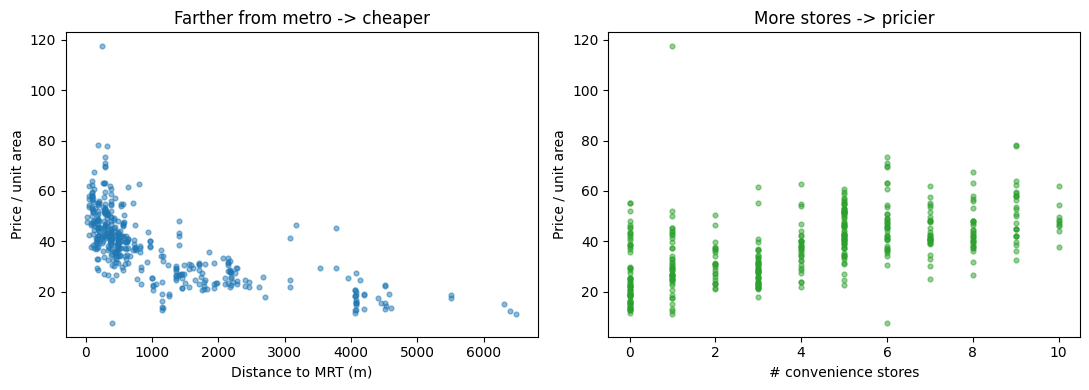

In [ ]:
# Visualise the two strongest relationships to build intuition.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(df["dist_mrt"], df["price"], s=12, alpha=0.5)
axes[0].set(xlabel="Distance to MRT (m)", ylabel="Price / unit area",
            title="Farther from metro -> cheaper")
axes[1].scatter(df["n_stores"], df["price"], s=12, alpha=0.5, color="tab:green")
axes[1].set(xlabel="# convenience stores", ylabel="Price / unit area",
            title="More stores -> pricier")
plt.tight_layout()
plt.show()

## 4. Define features `X` and target `y`, then split **honestly**

The single most important discipline in Week 1: **split before you fit anything.**
The test set is touched exactly once, at the very end. Any scaling/encoding must
be learned on the *training* data only — otherwise information leaks from test to
train and your reported score is a lie.

In [ ]:
# Separate predictors (X) from the target (y)
FEATURES = ["txn_date", "house_age", "dist_mrt", "n_stores", "lat", "lon"]
TARGET = "price"

X = df[FEATURES]
y = df[TARGET]

# 80% train / 20% test. random_state makes the split reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train rows: {len(X_train)}   Test rows: {len(X_test)}")
print(f"Mean price  -> train: {y_train.mean():.2f}   test: {y_test.mean():.2f}")

Train rows: 331   Test rows: 83
Mean price  -> train: 38.39   test: 36.34


## 5. The baseline *always ship this first*

Before any learning, ask: **how well do we do by predicting the mean price every
time?** That is the floor. If a model can't beat this, it adds no value.

`DummyRegressor(strategy="mean")` formalises exactly this baseline.

In [ ]:
# Fit the baseline on TRAIN only, evaluate on TEST.
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
base_pred = baseline.predict(X_test)

base_rmse = np.sqrt(mean_squared_error(y_test, base_pred))
base_mae  = mean_absolute_error(y_test, base_pred)
base_r2   = r2_score(y_test, base_pred)   # ~0 by construction: explains no variance

print("BASELINE (predict the mean):")
print(f"  RMSE = {base_rmse:.3f}")
print(f"  MAE  = {base_mae:.3f}")
print(f"  R^2  = {base_r2:.3f}")

BASELINE (predict the mean):
  RMSE = 13.114
  MAE  = 10.917
  R^2  = -0.025


## 6. The model Linear Regression (inside a leak-free Pipeline)

We wrap **StandardScaler → LinearRegression** in a `Pipeline`. Why a pipeline?
Because `fit()` learns the scaler's mean/std on the *training folds only*, so
there is **no train/test contamination**. Scaling doesn't change linear
regression's predictions, but it makes the coefficients directly comparable in
size (each is "price change per 1 standard deviation of that feature").

$$\hat{y} = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p$$

Linear regression finds the coefficients $\beta$ that minimise the sum of
squared errors on the training data the empirical risk from the lecture.

In [ ]:
# Build the pipeline: scale, then fit a linear model.
model = Pipeline(steps=[
                        ("scaler", StandardScaler()),
                        ("linreg", LinearRegression()),
                    ])

# Train on the training set only.
model.fit(X_train, y_train)

# Predict on the held-out test set.
y_pred = model.predict(X_test)

# Evaluate with the same metrics as the baseline (apples-to-apples).
lin_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lin_mae  = mean_absolute_error(y_test, y_pred)
lin_r2   = r2_score(y_test, y_pred)

print("LINEAR REGRESSION:")
print(f"  RMSE = {lin_rmse:.3f}")
print(f"  MAE  = {lin_mae:.3f}")
print(f"  R^2  = {lin_r2:.3f}")

LINEAR REGRESSION:
  RMSE = 7.315
  MAE  = 5.305
  R^2  = 0.681


## 7. Report **lift over baseline**

A raw RMSE means little on its own. What matters is: *how much better than the
trivial baseline is our model?*

In [ ]:
rmse_lift = (base_rmse - lin_rmse) / base_rmse * 100
mae_lift  = (base_mae  - lin_mae)  / base_mae  * 100

summary = pd.DataFrame({
                    "RMSE": [base_rmse, lin_rmse],
                    "MAE":  [base_mae,  lin_mae],
                    "R^2":  [base_r2,   lin_r2],
                }, index=["Baseline (mean)", "Linear Regression"])

print(summary.round(3))
print(f"\nLinear regression reduces RMSE by {rmse_lift:.1f}% vs the baseline.")
print(f"Linear regression reduces MAE  by {mae_lift:.1f}% vs the baseline.")
print(f"It explains {lin_r2*100:.1f}% of the variance in price (R^2).")

                     RMSE     MAE     R^2
Baseline (mean)   13.1140 10.9170 -0.0250
Linear Regression  7.3150  5.3050  0.6810

Linear regression reduces RMSE by 44.2% vs the baseline.
Linear regression reduces MAE  by 51.4% vs the baseline.
It explains 68.1% of the variance in price (R^2).


## 8. Cross-validation — *cheap insurance*

A single train/test split can be lucky or unlucky. **k-fold cross-validation**
averages performance over k different splits, giving a more stable estimate (and
its spread). We keep the test set sealed and cross-validate on the *training*
data only.

In [ ]:
# 5-fold CV on the training data. We score by RMSE (negated by sklearn convention).
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
neg_mse = cross_val_score(model, X_train, y_train,
                          scoring="neg_mean_squared_error", cv=kf)
cv_rmse = np.sqrt(-neg_mse)

print("5-fold CV RMSE on training data:")
print("  folds:", np.round(cv_rmse, 3))
print(f"  mean  = {cv_rmse.mean():.3f}   std = {cv_rmse.std():.3f}")
print(f"\nTest-set RMSE ({lin_rmse:.3f}) sits within the CV range "
      "-> the estimate looks stable (no obvious overfitting).")

5-fold CV RMSE on training data:
  folds: [ 7.779 13.46   8.85   7.105  8.36 ]
  mean  = 9.111   std = 2.252

Test-set RMSE (7.315) sits within the CV range -> the estimate looks stable (no obvious overfitting).


## 9. Interpreting the coefficients

Because features were standardised, each coefficient is the expected change in
price for a **one-standard-deviation** increase in that feature, holding the
others fixed. Bigger magnitude = more influence; sign = direction.

Intercept (mean price at average feature values): 38.392

Standardised coefficients (impact per 1 std dev):
dist_mrt    -5.7870
n_stores     3.2190
house_age   -3.0630
lat          2.8550
txn_date     1.5300
lon         -0.4410
dtype: float64


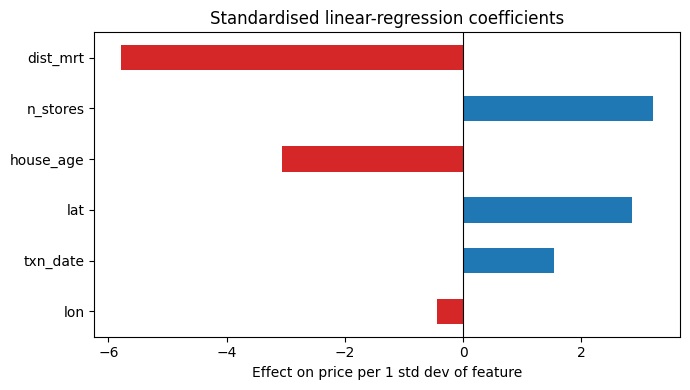

In [ ]:
# Pull the fitted pieces out of the pipeline.
lin = model.named_steps["linreg"]

coefs = (pd.Series(lin.coef_, index=FEATURES)
           .sort_values(key=np.abs, ascending=False))

print(f"Intercept (mean price at average feature values): {lin.intercept_:.3f}\n")
print("Standardised coefficients (impact per 1 std dev):")
print(coefs.round(3))

# Quick horizontal bar chart of the coefficients.
plt.figure(figsize=(7, 4))
coefs.iloc[::-1].plot(kind="barh",
    color=["tab:red" if c < 0 else "tab:blue" for c in coefs.iloc[::-1]])
plt.axvline(0, color="black", lw=0.8)
plt.title("Standardised linear-regression coefficients")
plt.xlabel("Effect on price per 1 std dev of feature")
plt.tight_layout()
plt.show()

## 10. Diagnostic plots

Two standard checks for a regression model:
1. **Predicted vs actual** — points should hug the 45° line.
2. **Residuals vs predicted** — residuals should scatter around zero with no
   obvious pattern (patterns hint at non-linearity the linear model misses).

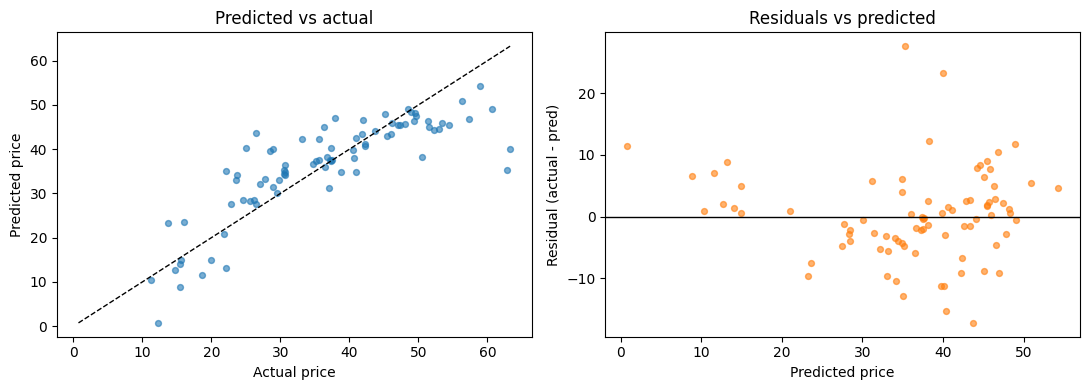

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (1) Predicted vs actual
axes[0].scatter(y_test, y_pred, s=18, alpha=0.6)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "k--", lw=1)          # perfect-prediction line
axes[0].set(xlabel="Actual price", ylabel="Predicted price",
            title="Predicted vs actual")

# (2) Residuals vs predicted
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, s=18, alpha=0.6, color="tab:orange")
axes[1].axhline(0, color="black", lw=1)
axes[1].set(xlabel="Predicted price", ylabel="Residual (actual - pred)",
            title="Residuals vs predicted")

plt.tight_layout()
plt.show()